# Лабораторная работа №1
## Графовый анализ публикаций по Retrieval-Augmented Generation

**Цель.** Собрать и исследовать корпус научных публикаций по RAG, извлечь ключевые термины, построить граф ключевых слов и граф публикаций, а затем найти близкие к выбранной статье работы.

Работа построена как единый эксперимент: данные → очистка текста → ключевые слова → графы → интерпретация результатов.

## 1. Библиотеки и параметры эксперимента

**Вход:** публикации arXiv.  
**Преобразование:** задаются все численные параметры, чтобы они не были «магическими числами» в коде.  
**Выход:** единые настройки анализа.

`N_ARTICLES` фиксирует объём корпуса, `TOP_KEYWORDS` — число признаков одной статьи. `MIN_DF` и `MAX_DF` убирают очень редкие и почти универсальные термины. Для графа ключевых слов далее сравниваются несколько порогов веса; итоговый порог выбирается по читаемости графа.

In [1]:
from __future__ import annotations

import json
import re
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
from IPython.display import display
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

DATA_PATH = Path('data/rag_arxiv_2020plus.json')
N_ARTICLES = 400
TOP_KEYWORDS = 10
MIN_DF = 5
MAX_DF = 0.55
EDGE_WEIGHT_CANDIDATES = (1, 2, 3, 5)
SELECTED_MIN_EDGE_WEIGHT = 3
RANDOM_SEED = 17

# WordNet — библиотечный лемматизатор; при первом запуске в Colab ресурс скачивается.
try:
    lemmatizer = WordNetLemmatizer()
    _ = lemmatizer.lemmatize('models')
except LookupError:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    lemmatizer = WordNetLemmatizer()

print('Параметры:', {'N_ARTICLES': N_ARTICLES, 'TOP_KEYWORDS': TOP_KEYWORDS, 'MIN_DF': MIN_DF, 'MAX_DF': MAX_DF, 'EDGE_WEIGHT_CANDIDATES': EDGE_WEIGHT_CANDIDATES, 'SELECTED_MIN_EDGE_WEIGHT': SELECTED_MIN_EDGE_WEIGHT})

Параметры: {'N_ARTICLES': 400, 'TOP_KEYWORDS': 10, 'MIN_DF': 5, 'MAX_DF': 0.55, 'EDGE_WEIGHT_CANDIDATES': (1, 2, 3, 5), 'SELECTED_MIN_EDGE_WEIGHT': 3}


## 2. Получение данных через arXiv API

**Вход:** поисковый запрос `all:"retrieval augmented generation"`.  
**Преобразование:** arXiv API возвращает Atom-записи; из каждой записи извлекаются ID, дата, название, авторы, аннотация и категории.  
**Выход:** JSON-снимок корпуса в `data/rag_arxiv_2020plus.json`.

Функция ниже использовалась для выгрузки. В ноутбуке далее загружается сохранённый снимок: так повторный запуск не меняет состав корпуса из-за появления новых статей в arXiv.

In [2]:
import time
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET

ARXIV_QUERY = 'all:"retrieval augmented generation"'
ARXIV_NS = {'atom': 'http://www.w3.org/2005/Atom'}


def fetch_arxiv_records(query: str = ARXIV_QUERY, target: int = N_ARTICLES, batch_size: int = 100) -> list[dict]:
    """Получить не менее target уникальных статей arXiv, опубликованных с 2020 года."""
    collected, seen = [], set()
    for start in range(0, target + batch_size, batch_size):
        params = urllib.parse.urlencode({
            'search_query': query, 'start': start, 'max_results': batch_size,
            'sortBy': 'submittedDate', 'sortOrder': 'descending',
        })
        request = urllib.request.Request(
            f'https://export.arxiv.org/api/query?{params}',
            headers={'User-Agent': 'lab1-rag-graph/1.0 (educational)'},
        )
        with urllib.request.urlopen(request, timeout=90) as response:
            root = ET.fromstring(response.read())
        for entry in root.findall('atom:entry', ARXIV_NS):
            identifier = entry.findtext('atom:id', default='', namespaces=ARXIV_NS).rsplit('/', 1)[-1]
            published = entry.findtext('atom:published', default='', namespaces=ARXIV_NS)
            if not identifier or identifier in seen or published[:4] < '2020':
                continue
            seen.add(identifier)
            collected.append({
                'id': identifier,
                'published': published[:10],
                'title': ' '.join(entry.findtext('atom:title', default='', namespaces=ARXIV_NS).split()),
                'authors': '; '.join(author.findtext('atom:name', default='', namespaces=ARXIV_NS) for author in entry.findall('atom:author', ARXIV_NS)),
                'abstract': ' '.join(entry.findtext('atom:summary', default='', namespaces=ARXIV_NS).split()),
                'categories': '; '.join(category.attrib.get('term', '') for category in entry.findall('atom:category', ARXIV_NS)),
            })
            if len(collected) >= target:
                return collected
        time.sleep(3)
    return collected

print('Функция выгрузки определена; для анализа загружается зафиксированный JSON-снимок.')

Функция выгрузки определена; для анализа загружается зафиксированный JSON-снимок.


## 2. Загрузка и описание входных данных

**Вход:** JSON-файл с результатами запроса arXiv API `all:"retrieval augmented generation"`. Для каждой записи сохранены ID, дата, название, авторы, аннотация и категории.  
**Преобразование:** записи загружаются в таблицу.  
**Выход:** корпус из не менее чем 300 публикаций, пригодный для анализа.

В JSON хранится исходная выгрузка; дальнейшие ключевые слова строятся заново ниже, поэтому результаты не зависят от ранее сохранённых производных полей.

In [3]:
records = json.loads(DATA_PATH.read_text(encoding='utf-8'))[:N_ARTICLES]
for record in records:
    record.pop('keywords', None)  # не используем старые производные признаки

df = pd.DataFrame(records)
assert len(df) >= 300, 'Для ЛР требуется не менее 300 публикаций'
assert {'id', 'published', 'title', 'authors', 'abstract'}.issubset(df.columns)

print(f'Публикаций: {len(df)}')
print(f"Период: {df['published'].min()} — {df['published'].max()}")
display(df[['id', 'published', 'title', 'authors']].head(5))

Публикаций: 400
Период: 2026-08-07 — 2026-10-02


,id,published,title,authors
0,2610.03632v1,2026-10-02,World Embedding Benchmark,Yiqi Liu; Ruifeng Yuan; Yang Wang; Long Li; Fe...
1,2610.03421v1,2026-10-02,CLIMB: Confidence-Guided Complementary Evidenc...,Hang Gao; Wujiang Xu; Zhixing Zhang; Kai Mei; ...
2,2610.03136v1,2026-10-02,Investigating the Role of Reasoning-Language A...,Oliver Hauck; Mario Sanz-Guerrero; Katharina v...
3,2610.02926v1,2026-10-02,Output Language Confusion under Multilingual P...,Riju Marwah; Ritvik Garimella; Khusham Bansal;...
4,2610.02627v1,2026-10-02,Lost in the Request: How Communication Variati...,Feng Chen; Ritam Dutt; Atnaz Taheri; Alex Will...


## 3. Разведочный анализ

**Вход:** даты, названия и аннотации публикаций.  
**Преобразование:** считаются годы публикации и базовые характеристики корпуса.  
**Выход:** понимание размера и временного состава выборки.

Выборка содержит последние результаты запроса и удовлетворяет требованию задания: публикации вышли не раньше 2020 года.

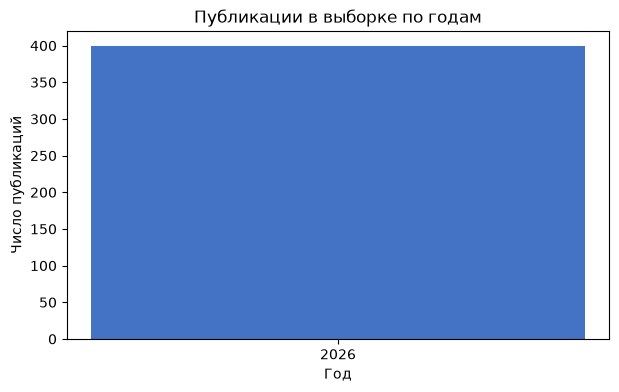

Токенов до очистки: 78,444


In [4]:
year_counts = df['published'].str[:4].value_counts().sort_index()
corpus = (df['title'] + ' ' + df['abstract']).tolist()
raw_token_count = sum(len(re.findall(r'[A-Za-z][A-Za-z-]+', text)) for text in corpus)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(year_counts.index, year_counts.values, color='#4472c4')
ax.set(title='Публикации в выборке по годам', xlabel='Год', ylabel='Число публикаций')
plt.show()
print(f'Токенов до очистки: {raw_token_count:,}')

## 4. Предобработка текста

**Вход:** объединённый `title + abstract` каждой статьи.  
**Преобразование:** нижний регистр → токенизация → удаление стандартных английских стоп-слов из `sklearn` → библиотечная лемматизация WordNet → удаление доменных стоп-слов RAG.  
**Выход:** нормализованные токены для n-грамм и TF-IDF.

Стандартные стоп-слова не поддерживаются вручную. Доменные стоп-слова оставлены отдельно: они часто встречаются из-за самого запроса и не помогают различать статьи внутри корпуса.

In [5]:
DOMAIN_STOPWORDS = {
    'retrieval', 'retrieve', 'augmented', 'generation', 'rag', 'model', 'system',
    'paper', 'approach', 'method', 'result', 'work', 'study', 'data', 'information'
}
TOKEN_RE = re.compile(r'[a-zA-Z][a-zA-Z-]{1,}')


def normalize_tokens(text: str) -> list[str]:
    tokens = TOKEN_RE.findall(text.lower())
    normalized = []
    for token in tokens:
        if token in ENGLISH_STOP_WORDS:
            continue
        # Сначала глагольная, затем именная лемматизация: documents -> document, retrieved -> retrieve.
        lemma = lemmatizer.lemmatize(lemmatizer.lemmatize(token, pos='v'), pos='n')
        if len(lemma) > 2 and lemma not in DOMAIN_STOPWORDS:
            normalized.append(lemma)
    return normalized

sample_before = corpus[0]
sample_after = normalize_tokens(sample_before)
cleaned_documents = [normalize_tokens(text) for text in corpus]
clean_token_count = sum(map(len, cleaned_documents))
vocabulary = set(token for tokens in cleaned_documents for token in tokens)

print('Пример исходного текста:', sample_before[:350], '...')
print('После обработки:', sample_after[:40])
print(f'Токенов после очистки: {clean_token_count:,}; словоформ: {len(vocabulary):,}')

Пример исходного текста: World Embedding Benchmark Physical fidelity has received increasing attention in world models and video generation, yet how video representations encode physical information remains less understood. We introduce the World Embedding Benchmark, comprising 8,000 controlled simulation cases from 80 families spanning fluid mechanics, solid mechanics, dy ...
После обработки: ['world', 'embed', 'benchmark', 'physical', 'fidelity', 'receive', 'increase', 'attention', 'world', 'video', 'video', 'representation', 'encode', 'physical', 'remain', 'understand', 'introduce', 'world', 'embed', 'benchmark', 'comprise', 'control', 'simulation', 'case', 'family', 'span', 'fluid', 'mechanic', 'solid', 'mechanic', 'dynamic', 'optic', 'electromagnetism', 'case', 'pair', 'render', 'video', 'simulation-derived', 'physical', 'annotation']
Токенов после очистки: 49,390; словоформ: 7,258


## 5. Извлечение ключевых слов: n-граммы и TF-IDF

**Вход:** очищенные и лемматизированные токены каждой статьи.  
**Преобразование:** формируются униграммы, биграммы и триграммы; TF-IDF оценивает их значимость, после чего сохраняются 10 терминов с наибольшим весом на статью.  
**Выход:** список ключевых терминов для каждой публикации.

N-граммы сохраняют смысл устойчивых выражений: `knowledge graph` точнее, чем слова `knowledge` и `graph` по отдельности. Жёсткого `max_features` нет: словарь ограничивается только частотой появления (`MIN_DF`, `MAX_DF`), а для каждой статьи затем выбираются top-10 терминов.

In [6]:
def ngram_analyzer(text: str) -> list[str]:
    tokens = normalize_tokens(text)
    grams = list(tokens)
    for n in (2, 3):
        grams.extend(' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1))
    return grams


def extract_tfidf_keywords(texts: list[str], top_k: int = TOP_KEYWORDS) -> tuple[list[list[str]], TfidfVectorizer]:
    vectorizer = TfidfVectorizer(analyzer=ngram_analyzer, min_df=MIN_DF, max_df=MAX_DF, sublinear_tf=True)
    matrix = vectorizer.fit_transform(texts)
    terms = np.asarray(vectorizer.get_feature_names_out())
    keyword_lists = []
    for row in matrix:
        row_values = row.toarray().ravel()
        top_indices = row_values.argsort()[-top_k:][::-1]
        keyword_lists.append(terms[top_indices].tolist())
    return keyword_lists, vectorizer

keyword_lists, vectorizer = extract_tfidf_keywords(corpus)
for record, keywords in zip(records, keyword_lists):
    record['keywords'] = keywords

print('Размер словаря TF-IDF:', len(vectorizer.get_feature_names_out()))
display(pd.DataFrame({'title': df['title'].head(5), 'keywords': keyword_lists[:5]}))

Размер словаря TF-IDF: 1802


,title,keywords
0,World Embedding Benchmark,"[physical, video, world, classification, regre..."
1,CLIMB: Confidence-Guided Complementary Evidenc...,"[multimodal, refinement, pool, complementary, ..."
2,Investigating the Role of Reasoning-Language A...,"[force, testbed, native, reason, english, alig..."
3,Output Language Confusion under Multilingual P...,"[multilingual, exact-match, abstention, clean,..."
4,Lost in the Request: How Communication Variati...,"[request, action, communication, formal, mainl..."


## 6. Проверка закона Ципфа

**Вход:** нормализованные униграммы корпуса.  
**Преобразование:** термины сортируются по частоте; на log-log графике строится частота в зависимости от ранга.  
**Выход:** визуальная проверка убывающего частотно-рангового распределения.

Для узкой тематической выборки наклон не обязан быть равен ровно −1: на него влияют доменные стоп-слова, лемматизация, объём корпуса и ограничение темы.

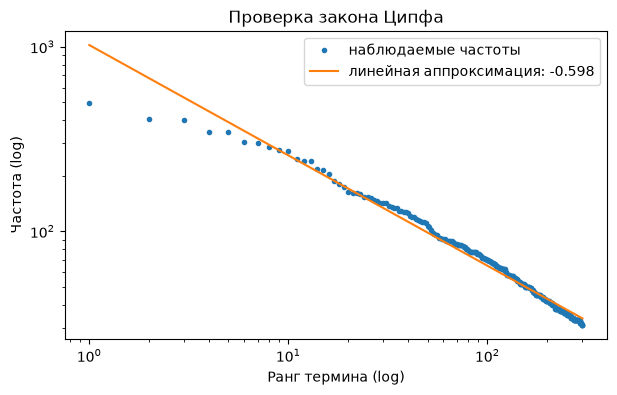

Наклон аппроксимации: -0.598


In [7]:
term_counts = Counter(token for tokens in cleaned_documents for token in tokens)
ranks = np.arange(1, min(300, len(term_counts)) + 1)
frequencies = np.array([count for _, count in term_counts.most_common(len(ranks))])
slope, intercept = np.polyfit(np.log(ranks), np.log(frequencies), 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ranks, frequencies, 'o', markersize=3, label='наблюдаемые частоты')
ax.loglog(ranks, np.exp(intercept) * ranks ** slope, label=f'линейная аппроксимация: {slope:.3f}')
ax.set(title='Проверка закона Ципфа', xlabel='Ранг термина (log)', ylabel='Частота (log)')
ax.legend()
plt.show()
print(f'Наклон аппроксимации: {slope:.3f}')

## 7. Граф ключевых слов и выбор порога связи

**Вход:** 10 TF-IDF-терминов каждой публикации.  
**Преобразование:** для каждой пары терминов в одной статье добавляется или увеличивается ребро; вес — число публикаций с этой парой. Затем сравниваются пороги `weight ≥ 1, 2, 3, 5`.  
**Выход:** взвешенный граф ключевых слов и обоснованный порог для интерпретации.

Порог `weight ≥ 3` выбран как компромисс: связи, встретившиеся в одной-двух статьях, часто случайны, а более высокий порог начинает убирать заметную часть тематических терминов. Сравнительная таблица ниже делает выбор явным.

In [8]:
def build_keyword_graph(keyword_lists: list[list[str]]) -> nx.Graph:
    graph = nx.Graph()
    for keywords in keyword_lists:
        unique = sorted(set(keywords))
        graph.add_nodes_from(unique)
        for left, right in combinations(unique, 2):
            if graph.has_edge(left, right):
                graph[left][right]['weight'] += 1
            else:
                graph.add_edge(left, right, weight=1)
    return graph


def filter_keyword_graph(graph: nx.Graph, min_weight: int) -> nx.Graph:
    filtered = graph.copy()
    filtered.remove_edges_from([(u, v) for u, v, attrs in filtered.edges(data=True) if attrs['weight'] < min_weight])
    filtered.remove_nodes_from(list(nx.isolates(filtered)))
    return filtered

full_keyword_graph = build_keyword_graph(keyword_lists)
threshold_rows = []
for threshold in EDGE_WEIGHT_CANDIDATES:
    candidate = filter_keyword_graph(full_keyword_graph, threshold)
    communities = list(nx.community.greedy_modularity_communities(candidate, weight='weight')) if candidate.number_of_edges() else []
    threshold_rows.append({
        'min_weight': threshold,
        'nodes': candidate.number_of_nodes(),
        'edges': candidate.number_of_edges(),
        'density': nx.density(candidate),
        'communities': len(communities),
        'modularity': nx.community.modularity(candidate, communities, weight='weight') if communities else np.nan,
    })
threshold_table = pd.DataFrame(threshold_rows).round(3)
display(threshold_table)

keyword_graph = filter_keyword_graph(full_keyword_graph, SELECTED_MIN_EDGE_WEIGHT)
print(f'Выбранный граф: {keyword_graph.number_of_nodes()} вершин, {keyword_graph.number_of_edges()} рёбер.')

,min_weight,nodes,edges,density,communities,modularity
0,1,1384,17252,0.018,7,0.310
1,2,406,607,0.007,39,0.745
2,3,85,85,0.024,20,0.787
3,5,13,10,0.128,4,0.674


Выбранный граф: 85 вершин, 85 рёбер.


### Визуализация графа ключевых слов

Вершины — ключевые слова и словосочетания. Толщина ребра отражает число публикаций, в которых термины встретились вместе. Подписаны наиболее важные вершины, чтобы граф оставался читаемым.

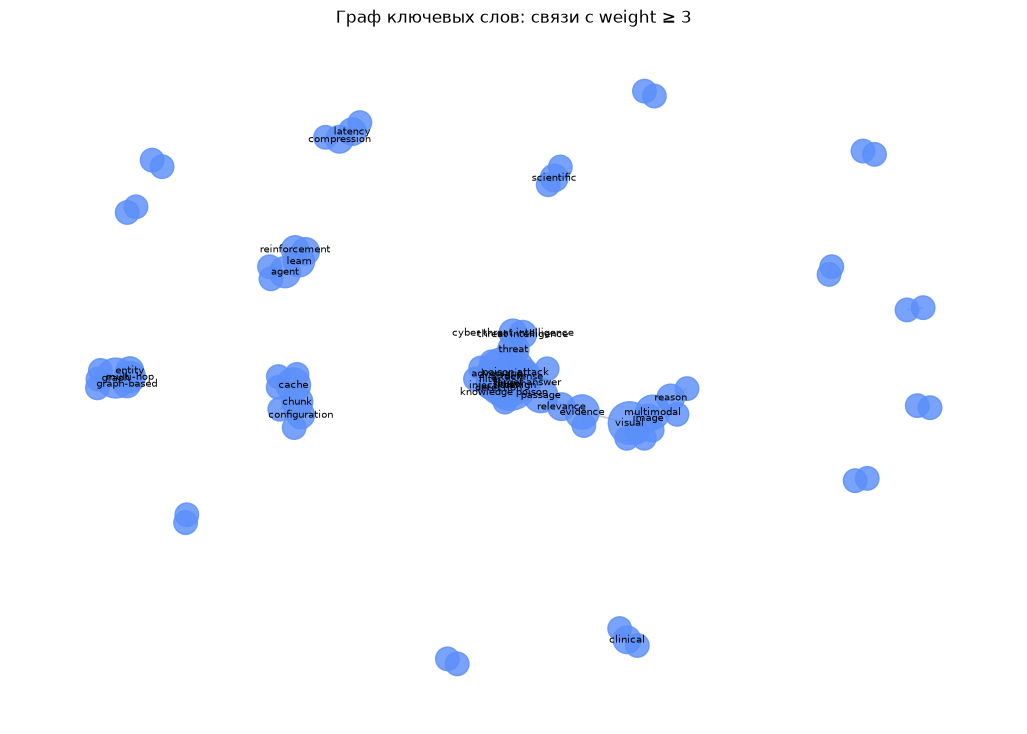

In [9]:
degree = nx.degree_centrality(keyword_graph)
for _, _, attrs in keyword_graph.edges(data=True):
    attrs['distance'] = 1 / attrs['weight']  # сильная связь должна быть коротким путём

pos = nx.spring_layout(keyword_graph, seed=RANDOM_SEED, weight='weight')
fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_nodes(keyword_graph, pos, node_size=[180 + 9000 * degree[node] for node in keyword_graph], node_color='#5b8ff9', alpha=.82, ax=ax)
nx.draw_networkx_edges(keyword_graph, pos, width=[0.25 + attrs['weight'] / 3 for _, _, attrs in keyword_graph.edges(data=True)], alpha=.22, ax=ax)
labels = {node: node for node in sorted(keyword_graph, key=lambda node: degree[node], reverse=True)[:35]}
nx.draw_networkx_labels(keyword_graph, pos, labels, font_size=7, ax=ax)
ax.set_title('Граф ключевых слов: связи с weight ≥ 3')
ax.axis('off')
plt.show()

## 8. Анализ графа: сообщества и центральности

**Вход:** отфильтрованный граф ключевых слов.  
**Преобразование:** сообщества находятся алгоритмом greedy modularity; рассчитываются degree, betweenness и eigenvector centrality. Для betweenness используется `distance = 1 / weight`, потому что большой вес означает сильную, а не длинную связь.  
**Выход:** тематические кластеры и список важных/связующих терминов.

Число вершин графа ключевых слов не обязано совпадать с числом статей: здесь вершины — только оставшиеся после TF-IDF и фильтрации термины, тогда как в следующем графе вершина — сама публикация.

In [10]:
communities = list(nx.community.greedy_modularity_communities(keyword_graph, weight='weight'))
modularity = nx.community.modularity(keyword_graph, communities, weight='weight')
betweenness = nx.betweenness_centrality(keyword_graph, weight='distance')
eigenvector = nx.eigenvector_centrality(keyword_graph, weight='weight', max_iter=2000)

centrality = pd.DataFrame({
    'term': list(keyword_graph.nodes()),
    'degree': [degree[node] for node in keyword_graph],
    'betweenness': [betweenness[node] for node in keyword_graph],
    'eigenvector': [eigenvector[node] for node in keyword_graph],
}).sort_values('eigenvector', ascending=False)

community_rows = []
for number, community in enumerate(sorted(communities, key=len, reverse=True), 1):
    top_terms = sorted(community, key=lambda term: eigenvector[term], reverse=True)[:8]
    community_rows.append({'community': number, 'size': len(community), 'top_terms': ', '.join(top_terms)})

print(f'Сообществ: {len(communities)}; modularity: {modularity:.3f}')
print('Топ-10 терминов по eigenvector centrality:')
display(centrality.head(10).round(3))
print('Сообщества:')
display(pd.DataFrame(community_rows))

Сообществ: 20; modularity: 0.787
Топ-10 терминов по eigenvector centrality:


,term,degree,betweenness,eigenvector
8,attack,0.190,0.092,0.611
52,poison,0.143,0.036,0.583
18,defense,0.048,0.009,0.267
17,benign,0.036,0.000,0.171
27,detection,0.024,0.000,0.164
67,poison attack,0.024,0.000,0.164
72,injection,0.024,0.000,0.144
75,knowledge poison,0.024,0.000,0.143
66,adversarial,0.024,0.000,0.143
3,passage,0.048,0.075,0.126


Сообщества:


,community,size,top_terms
0,1,17,"attack, poison, defense, benign, poison attack..."
1,2,10,"visual, multimodal, image, textual, visual evi..."
2,3,8,"cache, chunk, reuse, configuration, key-value,..."
3,4,7,"graph, multi-hop, graph-based, entity, graphra..."
4,5,6,"learn, reinforcement, reinforcement learn, age..."
5,6,4,"passage, evidence, relevance, candidate"
6,7,4,"compression, latency, budget, workload"
7,8,3,"scientific, research, literature"
8,9,3,"clinical, cancer, treatment"
9,10,3,"threat, cyber threat intelligence, threat inte..."


**Краткая интерпретация.** Degree показывает, сколько прямых связей у термина; betweenness показывает термин-мост между частями графа; eigenvector повышает важность вершин, связанных с другими важными вершинами. Модулярность описывает, насколько сообщества отделены друг от друга. Для RAG умеренная модулярность ожидаема: retrieval, документы, генерация, оценивание и агенты используют общие понятия.

## 9. Взвешенный граф публикаций и поиск похожих работ

**Вход:** публикации и их top-10 ключевых терминов.  
**Преобразование:** статьи соединяются, если имеют хотя бы один общий ключевой термин; вес ребра равен числу общих терминов. Соседи выбранной статьи сортируются по этому весу.  
**Выход:** объяснимый поиск похожих публикаций.

Число вершин этого графа равно числу публикаций (400), потому что здесь вершина — статья, а не ключевое слово.

In [11]:
def build_publication_graph(records: list[dict]) -> nx.Graph:
    graph = nx.Graph()
    for record in records:
        graph.add_node(record['id'], title=record['title'], keywords=record['keywords'])
    for left, right in combinations(records, 2):
        shared = sorted(set(left['keywords']) & set(right['keywords']))
        if shared:
            graph.add_edge(left['id'], right['id'], weight=len(shared), shared_keywords=shared)
    return graph


def nearest_publications(graph: nx.Graph, publication_id: str, top_k: int = 5) -> pd.DataFrame:
    rows = []
    for neighbor, attrs in graph[publication_id].items():
        rows.append({
            'id': neighbor,
            'title': graph.nodes[neighbor]['title'],
            'shared_keywords': attrs['weight'],
            'keywords': ', '.join(attrs['shared_keywords']),
        })
    return pd.DataFrame(rows).sort_values(['shared_keywords', 'id'], ascending=[False, True]).head(top_k)

publication_graph = build_publication_graph(records)
query_id = max(publication_graph.nodes, key=lambda node: publication_graph.degree(node))
results = nearest_publications(publication_graph, query_id)

print(f'Граф публикаций: {publication_graph.number_of_nodes()} вершин, {publication_graph.number_of_edges()} рёбер, плотность {nx.density(publication_graph):.3f}')
print('Запрос:', query_id)
print(publication_graph.nodes[query_id]['title'])
display(results)

Граф публикаций: 400 вершин, 7795 рёбер, плотность 0.098
Запрос: 2608.15056v1
GraphLoom: Reliability-Calibrated Graph Evidence Routing for Multimodal KG-RAG


,id,title,shared_keywords,keywords
60,2609.29695v1,EvLink: Source-Grounded Evidence Linking for G...,3,"evidence, graph, multi-hop"
0,2610.03421v1,CLIMB: Confidence-Guided Complementary Evidenc...,3,"evidence, multimodal, pool"
91,2608.07994v2,"VDGR-RAG: Vectors, Directories, Graphs, and Re...",2,"graph, rout"
85,2608.15919v1,Noesis: Bidirectional Graph-RAG with Adaptive ...,2,"graph, rout"
72,2608.25123v1,SelfGraphRAG: Bridging the Supervision Gap in ...,2,"graph, multi-hop"


## 10. Ограничения и выводы

Графовый поиск сравнивает публикации по отобранным TF-IDF-терминам. Его преимущество — прозрачность: для каждого результата видны общие ключевые слова. Ограничение — метод не улавливает семантическое сходство, если статьи используют разные слова для близкой идеи. Улучшение следующего уровня — эмбеддинги аннотаций и cosine similarity.

В работе собран корпус из 400 публикаций, проведены EDA и проверка закона Ципфа, извлечены униграммы, биграммы и триграммы, построены два разных взвешенных графа. Граф ключевых слов позволил найти тематические сообщества и центральные понятия, а граф публикаций — показать поиск ближайших работ по количеству общих ключевых терминов.